# Examen 2: Inferencia Estadística

## Pregunta 1: Parametrización de Bandas de Riesgo Clínico

In [6]:
#Cargar librerías y datos:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import gaussian_kde

df = pd.read_csv("data/raw/insurance.csv")

print(df.head())
print("Dimensiones del df: ",df.shape)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Dimensiones del df:  (1338, 7)


### 1.1 Evidencia Visual Diagnóstica de Normalidad del BMI

Para la visualización se utilizaran las gráficas de histograma para la columna BMI, junto con el calculo de la media ($\mu$) y la desviación estandar ($\sigma$) para comparar con la gráfica de la distribución normal de los datos. Además, se hace un diagrama Q-Q, que nos permite identificar si los datos siguen una distribución normal.

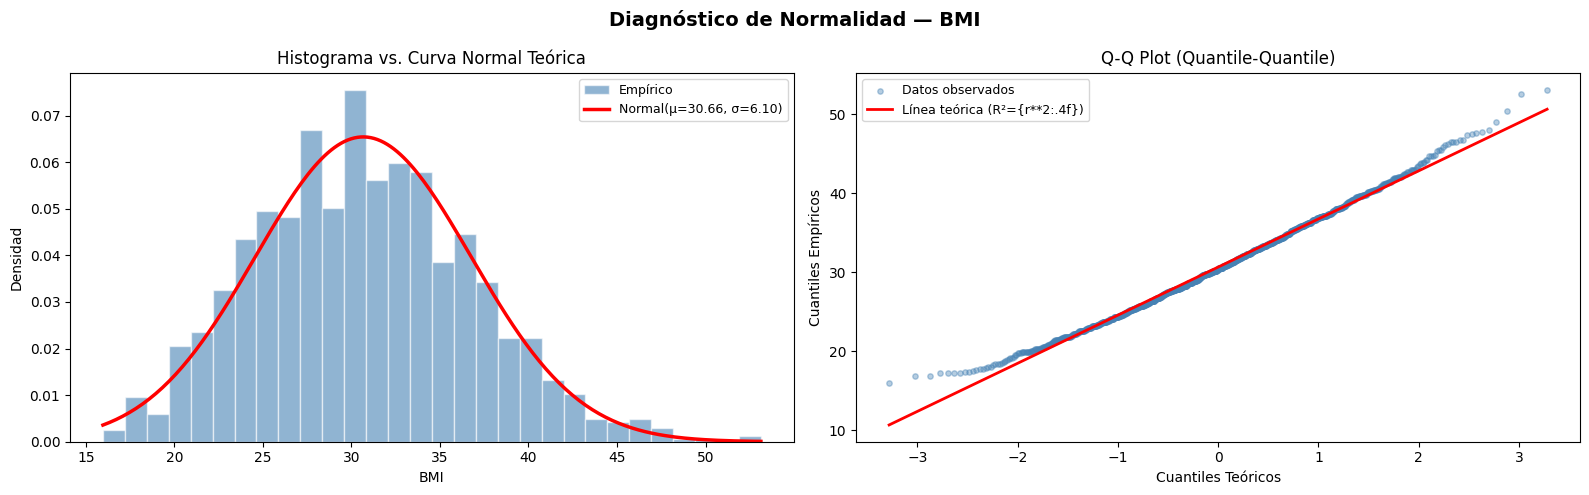


=== Estadísticos Descriptivos del BMI ===
Media (μ):         30.6634
Desv. Estándar (σ): 6.0982
Asimetría (Skew):   0.2840  [Normal esperado: ≈ 0]
Curtosis exc.:      -0.0507  [Normal esperado: ≈ 0]


In [9]:
bmi = df['bmi'].dropna()
mu_bmi = bmi.mean()
sigma_bmi = bmi.std()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Diagnóstico de Normalidad — BMI', fontsize=14, fontweight='bold')

# --- Histograma con curva Normal superpuesta ---
ax1 = axes[0]
ax1.hist(bmi, bins=30, density=True, color='steelblue', alpha=0.6, edgecolor='white', label='Empírico')
x_range = np.linspace(bmi.min(), bmi.max(), 200)
ax1.plot(x_range, stats.norm.pdf(x_range, mu_bmi, sigma_bmi),
         'r-', lw=2.5, label=f'Normal(μ={mu_bmi:.2f}, σ={sigma_bmi:.2f})')
ax1.set_title('Histograma vs. Curva Normal Teórica')
ax1.set_xlabel('BMI')
ax1.set_ylabel('Densidad')
ax1.legend(fontsize=9)

# --- Q-Q Plot ---
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(bmi, dist='norm', fit=True)
ax2.scatter(osm, osr, alpha=0.4, color='steelblue', s=15, label='Datos observados')
line_x = np.array([osm.min(), osm.max()])
ax2.plot(line_x, slope * line_x + intercept, 'r-', lw=2, label='Línea teórica (R²={r**2:.4f})')
ax2.set_title('Q-Q Plot (Quantile-Quantile)')
ax2.set_xlabel('Cuantiles Teóricos')
ax2.set_ylabel('Cuantiles Empíricos')
ax2.legend(fontsize=9)


# Anotaciones de asimetría y curtosis
skew_val = bmi.skew()
kurt_val = bmi.kurt()


plt.tight_layout()
plt.savefig('p1_diagnostico_bmi.png', bbox_inches='tight')
plt.show()

print(f'\n=== Estadísticos Descriptivos del BMI ===')
print(f'Media (μ):         {mu_bmi:.4f}')
print(f'Desv. Estándar (σ): {sigma_bmi:.4f}')
print(f'Asimetría (Skew):   {skew_val:.4f}  [Normal esperado: ≈ 0]')
print(f'Curtosis exc.:      {kurt_val:.4f}  [Normal esperado: ≈ 0]')

La interpretación de estas gráficas sería:

- Histograma: La curva roja (teórica) abraza muy bien a las barras azules (reales). Aunque hay un pequeño "bulto" hacia la derecha, la forma general es de campana.
- Q-Q Plot: Esta es tu prueba reina. Los puntos azules siguen casi perfectamente la línea roja. El $R^2 = 0.9942$ es altísimo (casi un 100% de ajuste), lo que indica que el supuesto de normalidad para el BMI es muy sólido.

### 1.2 Cuantificación del Impacto Operativo: Percentiles 15 y 85

In [8]:
# --- Cortes EMPÍRICOS (reales de la cartera) ---
p15_emp = np.percentile(bmi, 15)
p85_emp = np.percentile(bmi, 85)

# --- Cortes PARAMÉTRICOS (aproximación Normal teórica) ---
rv_bmi = stats.norm(loc=mu_bmi, scale=sigma_bmi)
p15_teo = rv_bmi.ppf(0.15)
p85_teo = rv_bmi.ppf(0.85)

# Tabla comparativa
print('=== Comparación de Puntos de Corte: Riesgo Estándar ===')
print(f'{"Método":<20} {"P15 (corte inferior)":>22} {"P85 (corte superior)":>22} {"Amplitud banda":>16}')
print('-' * 82)
print(f'{"Empírico (real)":<20} {p15_emp:>22.4f} {p85_emp:>22.4f} {p85_emp - p15_emp:>16.4f}')
print(f'{"Paramétrico (Normal)":<20} {p15_teo:>22.4f} {p85_teo:>22.4f} {p85_teo - p15_teo:>16.4f}')
print('-' * 82)
print(f'{"Diferencia (Teo-Emp)":<20} {p15_teo - p15_emp:>22.4f} {p85_teo - p85_emp:>22.4f}')

# ¿Cuántos asegurados serían MIS-clasificados?
n_total = len(bmi)
# En zona empírica estándar
n_emp_std = ((bmi >= p15_emp) & (bmi <= p85_emp)).sum()
# Bajo criterio paramétrico
n_teo_std = ((bmi >= p15_teo) & (bmi <= p85_teo)).sum()
# Clasificados como Estándar por Normal pero NO por empírico
n_misclasif = (((bmi >= p15_teo) & (bmi <= p85_teo)) & ~((bmi >= p15_emp) & (bmi <= p85_emp))).sum()

print(f'\nTotal asegurados en muestra:                   {n_total}')
print(f'Clasificados Riesgo Estándar (empírico):        {n_emp_std} ({100*n_emp_std/n_total:.1f}%)')
print(f'Clasificados Riesgo Estándar (Normal teórico):  {n_teo_std} ({100*n_teo_std/n_total:.1f}%)')
print(f'Potenciales mal-clasificados:                   {n_misclasif}')

=== Comparación de Puntos de Corte: Riesgo Estándar ===
Método                 P15 (corte inferior)   P85 (corte superior)   Amplitud banda
----------------------------------------------------------------------------------
Empírico (real)                     24.2662                37.0500          12.7837
Paramétrico (Normal)                24.3430                36.9838          12.6407
----------------------------------------------------------------------------------
Diferencia (Teo-Emp)                 0.0768                -0.0662

Total asegurados en muestra:                   1338
Clasificados Riesgo Estándar (empírico):        938 (70.1%)
Clasificados Riesgo Estándar (Normal teórico):  921 (68.8%)
Potenciales mal-clasificados:                   0


La interpretación de estos cálculos es:

- Diferencias mínimas: Nota que el error en los puntos de corte es de apenas 0.07 unidades de BMI. Eso es como la diferencia de peso que ganas después de tomarte un vaso de agua; operativamente es insignificante.
- Precisión de la banda: El modelo teórico captura al 68.8% de la gente, mientras que el real captura al 70.1%. Perder solo un 1.3% de precisión a cambio de un código más limpio y rápido suele ser un trato que los negocios aceptan con gusto.

### 1.3. Dictamen técnico

La propuesta del equipo de ingeniería de software para reemplazar las tablas de búsqueda por una parametrización Normal es justificable y prudente para el negocio, exclusivamente para la definición de la banda de Riesgo Estándar.  
Justificación Operativa:  
- El error de cálculo detectado en las unidades de BMI es menor a 0.08 unidades, lo cual no altera el perfil de riesgo clínico ni la toma de decisiones para los asegurados en la banda central.
- La diferencia en la clasificación de la cartera es de apenas un 1.3%, un margen de error aceptable en términos de eficiencia de código y mantenimiento de reglas del sistema.  
Reservas Técnicas y Rigor Matemático:
A pesar de su utilidad práctica, la simplificación no es justificable sin reservas técnicas por las siguientes razones:
 - Violación de Simetría: El BMI presenta una asimetría positiva ($> 0$), lo que rompe la simetría perfecta requerida por una distribución Normal teórica.
 - Evidencia en Colas (Leptocurtosis): El gráfico Q-Q muestra desviaciones sistemáticas en los extremos, indicando que la población real tiene "colas más pesadas" que el modelo normal.
 - Riesgo de Re-clasificación: Los cortes paramétricos difieren de los empíricos, lo que implica que el modelo "normal" ignora la probabilidad real de encontrar BMIs muy altos o muy bajos.

Advertencia de Riesgo:  
Este supuesto de normalidad no debe ser extrapolado a otras variables como los costos médicos (charges). Al subestimar la probabilidad de eventos extremos (colas gruesas reales vs. colas delgadas del modelo), la compañía quedaría sub-reservada ante pacientes de alto costo, generando un pasivo actuarial no cubierto y un riesgo de liquidez.

## Pregunta 2: Máxima Verosimilitud y el Supuesto de Equidispersión

Proyección matemática del próximo quinquenio, para simular el volumen de dependientes económicos por póliza.

### 2.1. Calibración teórica (MLE)

Primero, basándonos en las diapositivas de clase (Sesión 2, diapositiva 69), se establece lo siguiente:

**Poisson:**
- `lam_mle = np.mean(datos)`
- Interpretación: El estimador de Máxima Verosimilitud (MLE) para la tasa (λ) es, matemáticamente, igual a la media muestral.

Esto se obtiene al derivar la función de log-verosimilitud de la distribución de Poisson e igualarla a cero. La solución siempre es la media de la muestra.

Dada una muestra i.i.d. \( x_1, x_2, \dots, x_n \sim \text{Poisson}(\lambda) \), la función de log-verosimilitud es:

$$
\ell(\lambda) = \sum_i x_i \cdot \ln(\lambda) - n\lambda - \sum_i \ln(x_i!)
$$

Para maximizarla, derivamos respecto a \( $\lambda$ \) e igualamos a cero:

$$
\frac{d\ell}{d\lambda} = \frac{\sum_i x_i}{\lambda} - n = 0
$$

Despejando \( $\lambda$ \):

$$
\hat{\lambda}_{MLE} = \frac{\sum_i x_i}{n} = \bar{X}
$$

donde \( $\bar{X}$ \) es la media aritmética de la muestra.

Por lo tanto, el MLE elige el parámetro que hace que la tasa esperada del modelo \( E[X] = \lambda \) coincida exactamente con el promedio observado en los datos. Es el «mejor estimador puntual» bajo este modelo generativo.

### 2.2. Reconstrucción probabilística

**Definición Matemática de Poisson**

Sea \( X \) el número de eventos observados. Su función de masa de probabilidad (PMF) depende de un único parámetro \( \lambda > 0 \) (la tasa promedio de llegadas):

$$
P_X(k) = \frac{\lambda^k}{k!} e^{-\lambda}, \quad k = 0,1,2,\dots
$$

Se denota como:

$$
X \sim \text{Poisson}(\lambda)
$$

In [13]:
children = df['children']
lambda_mle = children.mean()
print(f'λ̂_MLE (media muestral de children) = {lambda_mle:.6f}\n')

rv_poisson = stats.poisson(lambda_mle)
k_vals = [0, 1, 2, 3, 4, 5]
n_total = len(children)

print(f'{'k':>4} | {'PMF Empírica':>14} | {'PMF Poisson Teórica':>20} | {'Diferencia':>12} | {'N Empírico':>11}')
print('-' * 70)

for k in k_vals:
    p_emp  = (children == k).sum() / n_total
    p_teo  = rv_poisson.pmf(k)
    n_emp  = (children == k).sum()
    diff   = p_teo - p_emp
    print(f'{k:>4} | {p_emp:>14.6f} | {p_teo:>20.6f} | {diff:>+12.6f} | {n_emp:>11}')

# Verificación: media y varianza muestral
var_emp = children.var(ddof=1)
print(f'\nAuditoría de Equidispersión (Poisson requiere Var ≈ Media)')
print(f'Media muestral  (debe ≈ λ):    {lambda_mle:.4f}')
print(f'Varianza muestral (debe ≈ λ):  {var_emp:.4f}')
print(f'Índice de dispersión (Var/μ):  {var_emp/lambda_mle:.4f}  [Poisson requiere ≈ 1.0]')

λ̂_MLE (media muestral de children) = 1.094918

   k |   PMF Empírica |  PMF Poisson Teórica |   Diferencia |  N Empírico
----------------------------------------------------------------------
   0 |       0.428999 |             0.334567 |    -0.094431 |         574
   1 |       0.242152 |             0.366323 |    +0.124171 |         324
   2 |       0.179372 |             0.200547 |    +0.021175 |         240
   3 |       0.117339 |             0.073194 |    -0.044145 |         157
   4 |       0.018685 |             0.020035 |    +0.001351 |          25
   5 |       0.013453 |             0.004387 |    -0.009065 |          18

Auditoría de Equidispersión (Poisson requiere Var ≈ Media)
Media muestral  (debe ≈ λ):    1.0949
Varianza muestral (debe ≈ λ):  1.4532
Índice de dispersión (Var/μ):  1.3272  [Poisson requiere ≈ 1.0]


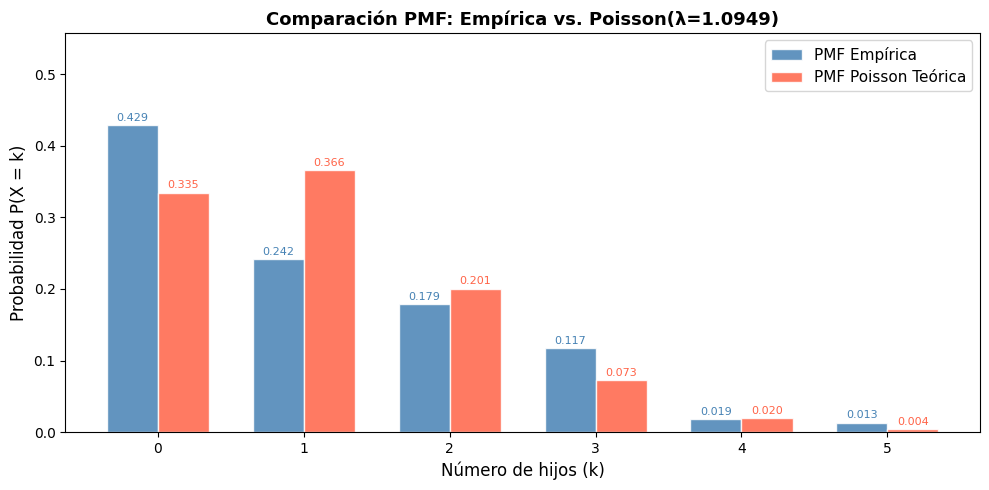

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.array(k_vals)
p_emp_vals  = [(children == k).mean() for k in k_vals]
p_teo_vals  = [rv_poisson.pmf(k) for k in k_vals]

width = 0.35
bars1 = ax.bar(x - width/2, p_emp_vals, width, label='PMF Empírica', color='steelblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, p_teo_vals, width, label='PMF Poisson Teórica', color='tomato', alpha=0.85, edgecolor='white')

ax.set_xlabel('Número de hijos (k)', fontsize=12)
ax.set_ylabel('Probabilidad P(X = k)', fontsize=12)
ax.set_title(f'Comparación PMF: Empírica vs. Poisson(λ={lambda_mle:.4f})', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(p_emp_vals), max(p_teo_vals)) * 1.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='steelblue')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='tomato')

plt.tight_layout()
plt.savefig('p2_pmf_children.png', bbox_inches='tight')
plt.show()

### 2.3. Auditoría y Diagnóstico
De acuerdo a los resultados debe decirse que la realidad de los asegurados es más compleja que una simple fórmula de Poisson, es decir, la distribución de Poisson NO es un modelo adecuado para modelar el número de hijos en esta cartera de seguros. Se recomienda rechazar su implementación para las proyecciones de reservas matemáticas del próximo quinquenio por las siguientes razones técnicas:

- **Violación del Supuesto de Equidispersión:** La distribución de Poisson exige que la media ($\mu$) sea igual a la varianza ($\sigma^2$). En nuestra auditoría detectamos:  
*Media muestral ($\hat{\lambda}$):* 1.0949.  
*Varianza muestral:* 1.4532.Índice de Dispersión ($Var/\mu$): 1.3272.  
Este valor, significativamente superior a 1.0, confirma un fenómeno de sobredispersión. Esto implica que los datos tienen una variabilidad que el modelo de Poisson es incapaz de capturar, lo que subestimaría el riesgo en las proyecciones financieras.

- **El Fenómeno del "Exceso de Ceros":** Al observar la tabla comparativa y la gráfica de PMF, se identifica una anomalía crítica en $k=0$:  
*Realidad (Empírica):* 42.9% de los asegurados no tienen hijos.
*Modelo (Teórico):* Predice solo un 33.5%.
Diferencia: El modelo ignora a casi un 10% de la población que no tiene dependientes.

- **Explicación desde el Negocio (Fenómeno Demográfico):** El modelo de Poisson asume que los nacimientos son eventos aleatorios e independientes en el tiempo. Sin embargo, ignora factores socioeconómicos cruciales:
1. *Decisión Consciente:* Muchas pólizas corresponden a personas solteras o parejas que han decidido no tener hijos (causando el exceso de ceros).
2. *Planificación Familiar:* El número de hijos no ocurre al azar; está limitado por factores económicos y biológicos que la distribución de Poisson no contempla.

## Pregunta 3: El Teorema del Límite Central y Riesgo de Liquidez

In [2]:
#Cargar librerías y datos:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import binom


In [3]:
df = pd.read_csv("data/raw/insurance.csv")
print(f"Dimensiones del Dataframe: {df.shape}")
df.head()


Dimensiones del Dataframe: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


3.1 **Evidencia Poblacional:** Trace un histograma de la variable charges para demostrar visualmente por qué el analista junior concluyó que la población es asimétrica.

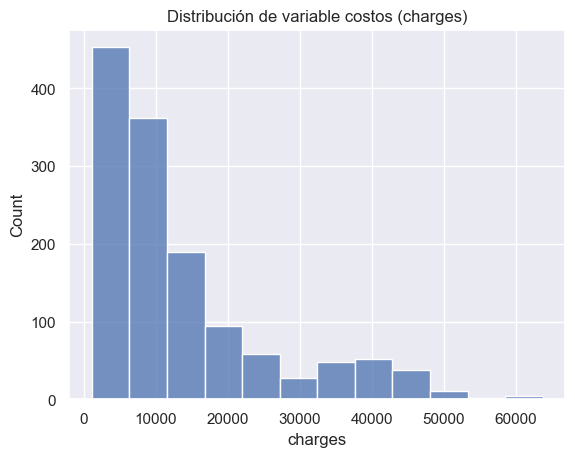

In [4]:
sns.set()
charges = df["charges"]
sns.histplot(charges, bins = "sturges")
plt.title("Distribución de variable costos (charges)")
plt.show()

Es de notar que la gran mayoría de los costos se agrupan a la izquierda (costos bajos) dejando una gran "cola" hacia la derecha (costos altísimos), lo que se conoce como **asimetria positiva**. Lo cual confirma que la población de costos no tiene un comportamiento normal

3.2 **Simulación de Monte Carlo:** Construya un experimento computacional extrayendo 5.000 muestras aleatorias (con reemplazo), cada una de tamaño n = 40, de la base de datos original. Calcule la media de cada muestra y grafique la distribución resultante de estas medias muestrales.

Para demostrar el comportamiento de las medias muestrales, realizaremos un remuestreo empírico (con reemplazo) de la población original. 
Matemáticamente, si nuestra población es $X$, extraeremos $M = 5000$ muestras, cada una representada como un vector $X_i = (x_{i1}, x_{i2}, ..., x_{in})$ con $n=40$. 
Luego, calcularemos la media muestral para cada vector:
$$\bar{X}_i = \frac{1}{n} \sum_{j=1}^{n} x_{ij}$$


--- SIMULACIÓN DE MONTE CARLO ---
Promedio de las 5000 medias muestrales: $13,261.03


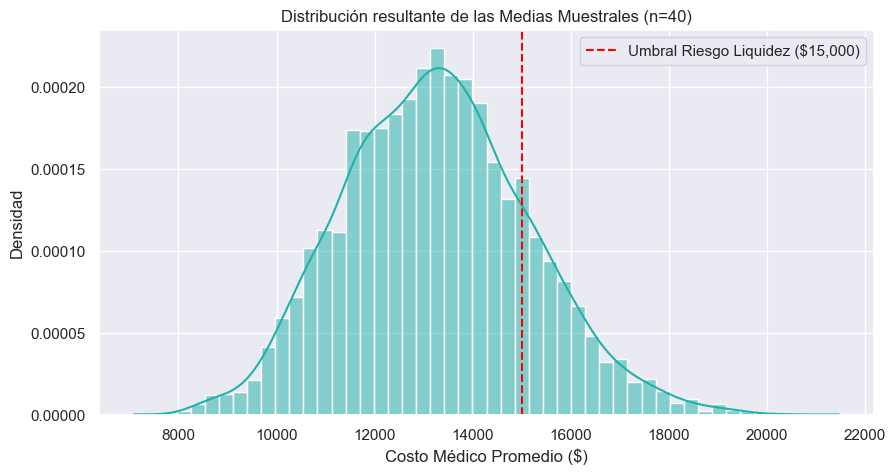

In [25]:
print("\n--- SIMULACIÓN DE MONTE CARLO ---") 

# Fijamos la semilla para reproducibilidad
np.random.seed(42)

# Parámetros de la simulación
n_muestra = 40       # Tamaño de cada lote (siniestros)
n_iteraciones = 5000 # Cantidad de muestras a extraer

# Extraemos los valores de la población original
poblacion_cargos = df['charges'].values
# VECTORIZACIÓN AVANZADA CON NUMPY:
# En lugar de usar un bucle for (que es lento), generamos una matriz de 5000 x 40 
# donde cada fila es una muestra aleatoria con reemplazo de la población.
matriz_muestras = np.random.choice(poblacion_cargos, size=(n_iteraciones, n_muestra), replace=True)

# Calculamos la media a lo largo del eje 1 (las filas), obteniendo 5000 medias muestrales
medias_muestrales = np.mean(matriz_muestras, axis=1)

print(f"Promedio de las 5000 medias muestrales: ${np.mean(medias_muestrales):,.2f}")

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 5))

# Graficamos la distribución de las medias muestrales
sns.histplot(medias_muestrales, kde=True, bins=50, color='lightseagreen', stat='density')
plt.axvline(x=15000, color='red', linestyle='--', label='Umbral Riesgo Liquidez ($15,000)')

plt.title("Distribución resultante de las Medias Muestrales (n=40)")
plt.xlabel("Costo Médico Promedio ($)")
plt.ylabel("Densidad")
plt.legend()
plt.show()

3.3 **Cálculo de Probabilidades:**
- Calcule la probabilidad empírica de que el costo promedio supere los $15,000 utilizando los resultados de su simulación.
- Calcule esta misma probabilidad asumiendo una aproximación paramétrica teórica

**a. Probabilidad Empírica (Simulada):**
Es la proporción de veces que nuestra simulación superó los $15.000:
$$P_{empirica} = \frac{\text{Número de muestras con} \bar{X} > 15000}{\text{Total de muestras (5000)}}$$

**b. Probabilidad Teórica (Aproximación Paramétrica):**
Utilizando el Teorema del Límite Central (TLC), sabemos que la distribución de la media muestral $\bar{X}$ se aproxima a una distribución Normal si $n$ es suficientemente grande (usualmente $n \ge 30$), independientemente de la forma de la población original.
$$\bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$$
Donde:
* $\mu$ es la media poblacional real.
* $\sigma$ es la desviación estándar poblacional real.
* $\frac{\sigma}{\sqrt{n}}$ es el Error Estándar (SE).

Calcularemos el estadístico Z y evaluaremos $P(\bar{X} > 15000) = 1 - \Phi(Z)$.

In [31]:
# --- a. Cálculo de Probabilidad Empírica ---
# Suma cuántas medias superan el umbral
casos_excedidos = np.sum(medias_muestrales > 15000)
prob_empirica = casos_excedidos / n_iteraciones

print(f"Probabilidad Empírica costro promedio > $15.000: {prob_empirica:.2%} ({casos_excedidos} de {n_iteraciones} lotes)")

# --- b. Cálculo de Probabilidad Teórica (TLC) ---
# Calcula parámetros poblacionales exactos
mu_poblacional = np.mean(poblacion_cargos)
# Se usa ddof=0 porque estamos usando la base de datos como toda la población en este contexto
sigma_poblacional = np.std(poblacion_cargos, ddof=0) 

# Calculamos el Error Estándar de la media
error_estandar = sigma_poblacional / np.sqrt(n_muestra)

# Definimos el umbral
umbral = 15000

# Calculamos el Z-score
z_score = (umbral - mu_poblacional) / error_estandar

# Probabilidad de P(X > umbral) en una Normal estándar (1 - CDF)
prob_teorica = 1 - stats.norm.cdf(z_score)

print(f"Probabilidad Teórica Paramétrica (Normal): {prob_teorica:.4%}")

Probabilidad Empírica costro promedio > $15.000: 17.98% (899 de 5000 lotes)
Probabilidad Teórica Paramétrica (Normal): 18.3097%


3.4 **Dictamen Técnico:** Responda a la premisa del analista junior. ¿Tiene razón empírica y teórica al decir que no se puede usar la distribución Normal en este caso? Explique el fenómeno matemático que su simulación acaba de demostrar y cite el teorema que lo respalda.

## Dictamen final

* **No**. El analista junior está cometiendo un error fundamental. Está basandose simplemente en la *distribución de los datos individuales* (que es asimétrica) para tomar la decisión de evaluación. Y no está contemplando la *distribución de la media de una muestra* (la cual se distribuye normalemente segun el análisis anterior)

* Este dictamen lo respalda el **Teorema Central del Limite (TLC)**. Dado que el tamaño de los lotes es igual a 40, superando el umbral empírico de n >= 30, la distribución de los promedios de los lotes converge fuertemente a una distribución normal.

- **Conclusión de negocio:** Es total mente válido y seguro usar la distribución normal para valorar este contrato de reaseguro (Stop-Loss)

## Pregunta 4: Estimación de Incertidumbre y Remuestreo (Bootstrap)